DISEASE PREDICTION MODEL

Dataset Loaded Successfully!
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst

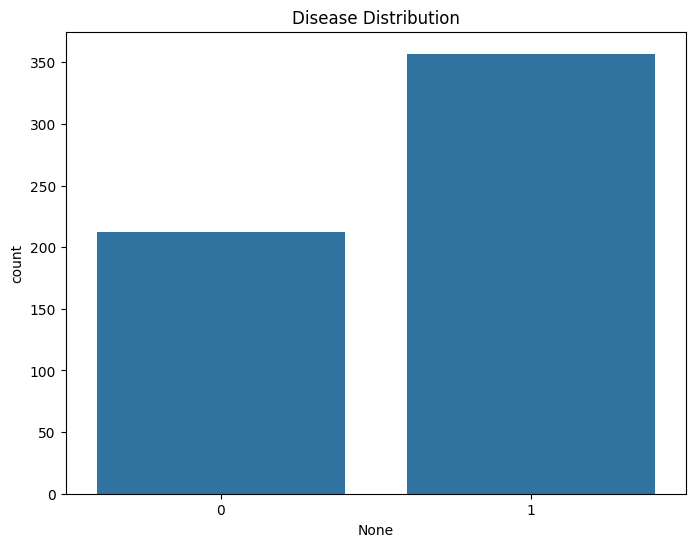


Training Samples : 455
Testing Samples : 114

Logistic Regression
Accuracy : 0.9736842105263158
Precision: 0.9722222222222222
Recall   : 0.9859154929577465
F1 Score : 0.9790209790209791

Random Forest
Accuracy : 0.9649122807017544
Precision: 0.958904109589041
Recall   : 0.9859154929577465
F1 Score : 0.9722222222222222

Model Comparison
                 Model  Accuracy
0  Logistic Regression  0.973684
1        Random Forest  0.964912


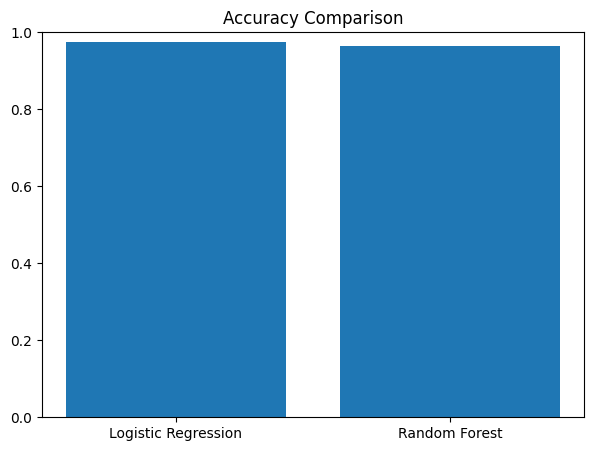

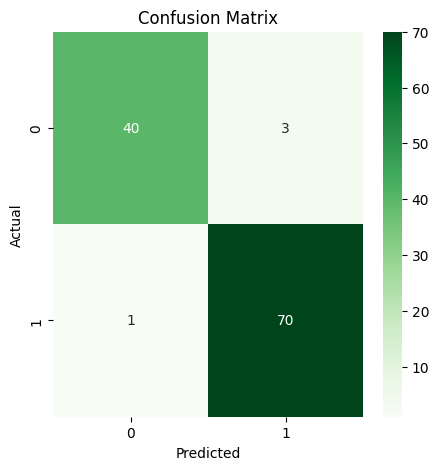


Classification Report
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

ROC AUC Score : 0.9959056665574845


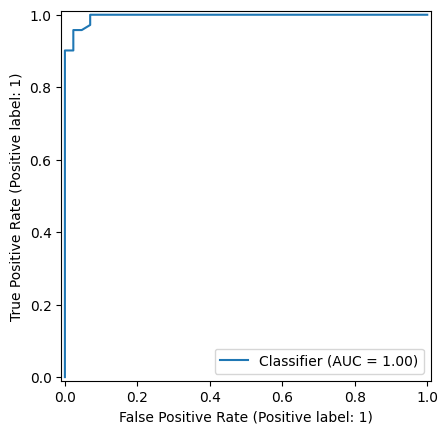

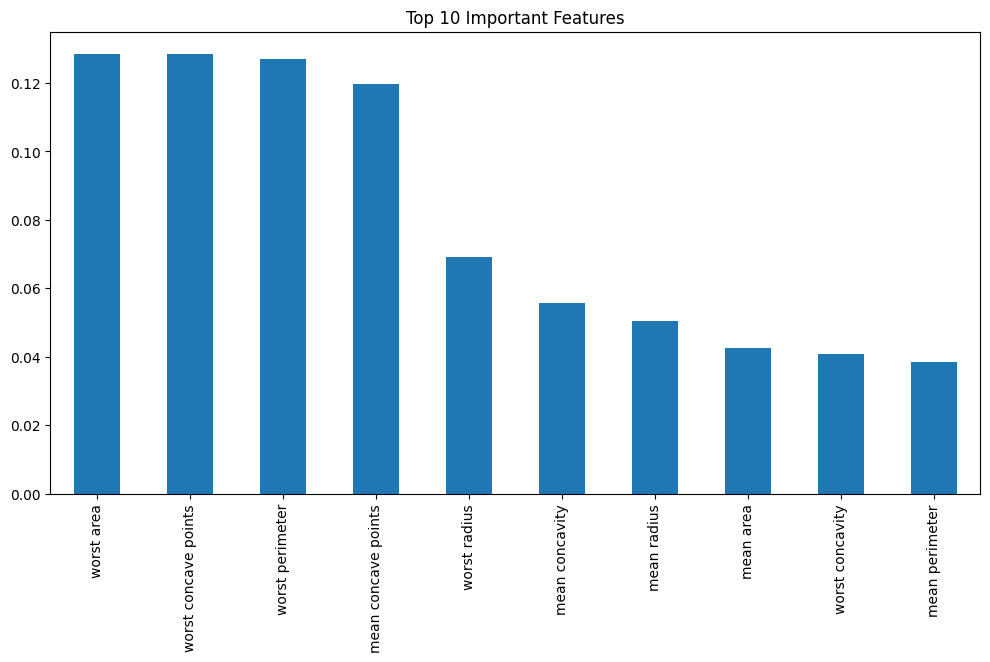


Sample Prediction
Prediction : Disease Detected

Model Saved Successfully!


In [1]:
!pip -q install pandas numpy matplotlib seaborn scikit-learn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay

print("="*60)
print("DISEASE PREDICTION MODEL")
print("="*60)

# Load Dataset
dataset = load_breast_cancer()

X = pd.DataFrame(dataset.data, columns=dataset.feature_names)
y = pd.Series(dataset.target)

print("\nDataset Loaded Successfully!")
print(X.head())

# Dataset Information
print("\nDataset Shape :", X.shape)

# Missing Values
print("\nMissing Values")
print(X.isnull().sum())

# Data Visualization
plt.figure(figsize=(8,6))
sns.countplot(x=y)
plt.title("Disease Distribution")
plt.show()

# Feature Scaling
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTraining Samples :", len(X_train))
print("Testing Samples :", len(X_test))

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Evaluation Function
def evaluate(name, pred):

    print("\n" + "="*50)
    print(name)
    print("="*50)

    print("Accuracy :", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred))
    print("Recall   :", recall_score(y_test, pred))
    print("F1 Score :", f1_score(y_test, pred))

evaluate("Logistic Regression", lr_pred)
evaluate("Random Forest", rf_pred)

# Accuracy Comparison
results = pd.DataFrame({
    "Model":["Logistic Regression","Random Forest"],
    "Accuracy":[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred)
    ]
})

print("\nModel Comparison")
print(results)

# Accuracy Graph
plt.figure(figsize=(7,5))
plt.bar(results["Model"], results["Accuracy"])
plt.title("Accuracy Comparison")
plt.ylim(0,1)
plt.show()

# Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Greens")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, rf_pred))

# ROC Curve
rf_prob = rf.predict_proba(X_test)[:,1]

roc = roc_auc_score(y_test, rf_prob)

print("ROC AUC Score :", roc)

RocCurveDisplay.from_predictions(y_test, rf_prob)
plt.show()

# Feature Importance
importance = pd.Series(
    rf.feature_importances_,
    index=dataset.feature_names
).sort_values(ascending=False)

plt.figure(figsize=(12,6))
importance.head(10).plot(kind="bar")
plt.title("Top 10 Important Features")
plt.show()

# Sample Prediction
sample = X_test[0].reshape(1,-1)

prediction = rf.predict(sample)

print("\nSample Prediction")

if prediction[0] == 1:
    print("Prediction : Disease Detected")
else:
    print("Prediction : No Disease")

# Save Model
joblib.dump(rf, "disease_prediction_model.pkl")

print("\nModel Saved Successfully!")